# Actividad 3.2: Carga y Exploración de Datos

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Para que los graficos se vean limpios
sns.set_theme(style="whitegrid")

# Carga el dataset
df = pd.read_csv('IRIS.csv')

print("¡Dataset Iris cargado con éxito!")

¡Dataset Iris cargado con éxito!


In [16]:
# Mostramos las primeras 10 lineas
df.head(10)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


In [17]:
# Información del dataset y el tipo de datos
print(" - - - Estructura de los Datos - - -")
df.info

 - - - Estructura de los Datos - - -


<bound method DataFrame.info of      sepal_length  sepal_width  petal_length  petal_width         species
0             5.1          3.5           1.4          0.2     Iris-setosa
1             4.9          3.0           1.4          0.2     Iris-setosa
2             4.7          3.2           1.3          0.2     Iris-setosa
3             4.6          3.1           1.5          0.2     Iris-setosa
4             5.0          3.6           1.4          0.2     Iris-setosa
..            ...          ...           ...          ...             ...
145           6.7          3.0           5.2          2.3  Iris-virginica
146           6.3          2.5           5.0          1.9  Iris-virginica
147           6.5          3.0           5.2          2.0  Iris-virginica
148           6.2          3.4           5.4          2.3  Iris-virginica
149           5.9          3.0           5.1          1.8  Iris-virginica

[150 rows x 5 columns]>

In [18]:
# Identificar si exiten valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())

# Estadistica básica 
print("\n- - - Resumen Estadístico - - -")
df.describe()

Valores nulos por columna:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

- - - Resumen Estadístico - - -


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


# Actividad 3.3 Limpieza de Datos

In [19]:
# Verificamos duplicados y nulos iniciales
print(f"Filas totales originales: {len(df)}")
print(f"Duplicados detectados: {df.duplicated().sum()}")
print(f"Nulos detectados:\n{df.isnull().sum()}")

Filas totales originales: 150
Duplicados detectados: 3
Nulos detectados:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [20]:
# Manejo de valores nulos
df.fillna(df.mean(numeric_only=True), inplace=True)

# Eliminar duplicados
df.drop_duplicates(inplace=True)

# Estandarizar el nombre de las columnas
df.columns = [col.lower().strip().replace(' ', '_') for col in df.columns]

# Creamos una nueva columna en donde simularemos el área de un petalo 
df['petal_area'] = df['sepal_length'] * df['sepal_width']

# Convertir tipo de datos
df['species'] = df['species'].astype('category')

In [21]:
print("--- Estado Después de la Limpieza ---")
print(f"Filas totales finales: {len(df)}")
print(f"Nombres de columnas actuales: {df.columns.tolist()}")
print("\nPrimeras filas del dataset transformado:")
print(df.head())

--- Estado Después de la Limpieza ---
Filas totales finales: 147
Nombres de columnas actuales: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species', 'petal_area']

Primeras filas del dataset transformado:
   sepal_length  sepal_width  petal_length  petal_width      species  \
0           5.1          3.5           1.4          0.2  Iris-setosa   
1           4.9          3.0           1.4          0.2  Iris-setosa   
2           4.7          3.2           1.3          0.2  Iris-setosa   
3           4.6          3.1           1.5          0.2  Iris-setosa   
4           5.0          3.6           1.4          0.2  Iris-setosa   

   petal_area  
0       17.85  
1       14.70  
2       15.04  
3       14.26  
4       18.00  


# Actividad 3.4: Visualización Exploratoria

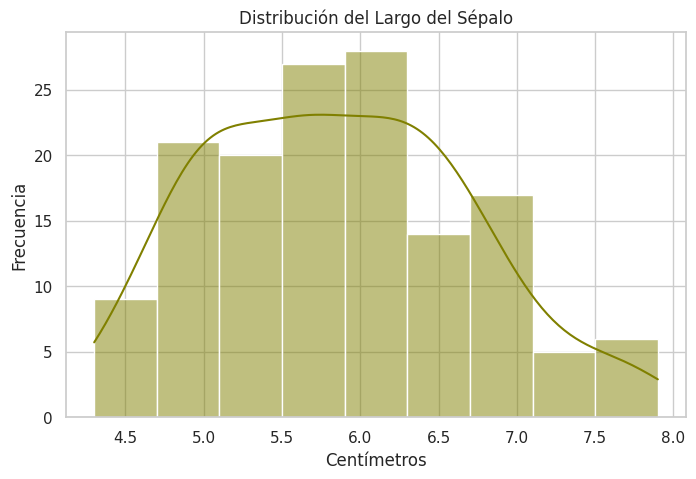

/tmp/ipykernel_35189/647078487.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='species', data=df, palette='viridis')


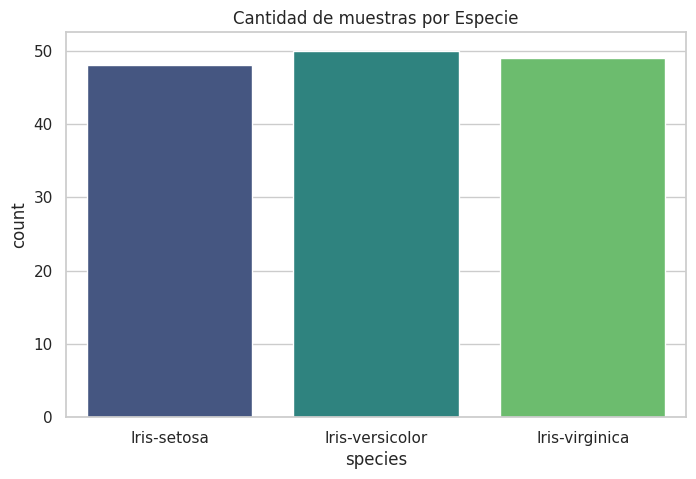

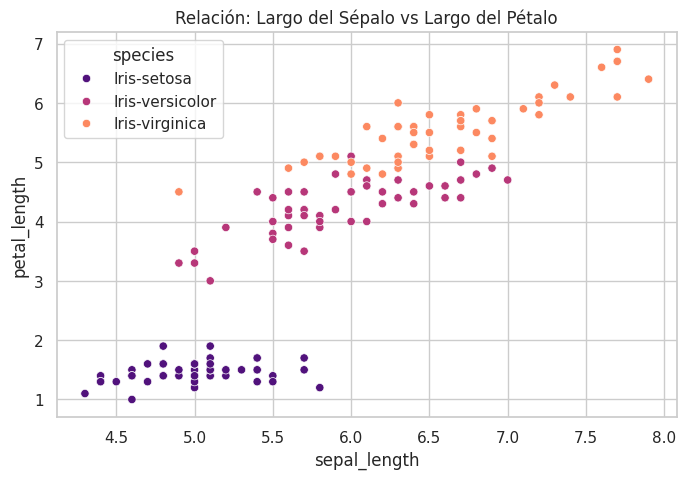

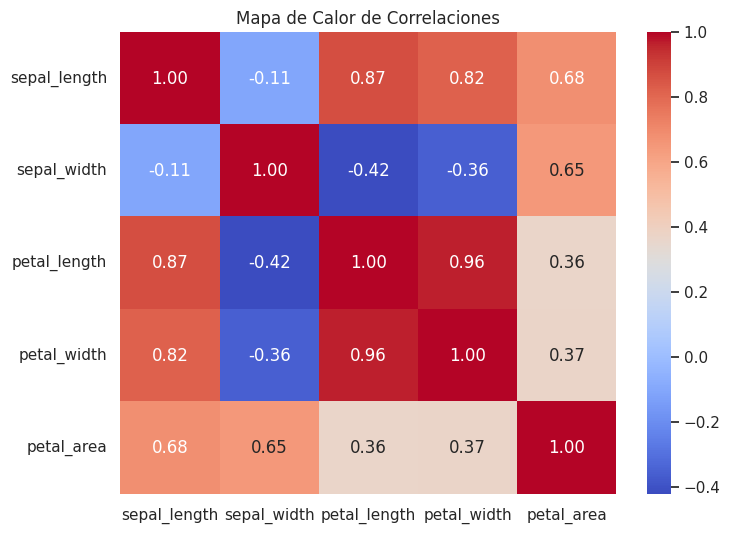

In [22]:
# Histograma del largo del sépalo
plt.figure(figsize=(8, 5))
sns.histplot(df['sepal_length'], kde=True, color='olive')
plt.title('Distribución del Largo del Sépalo')
plt.xlabel('Centímetros')
plt.ylabel('Frecuencia')
plt.savefig('histograma_sepalo.png')
plt.show()

# Gráfico de barras para conteo por especie
plt.figure(figsize=(8, 5))
sns.countplot(x='species', data=df, palette='viridis')
plt.title('Cantidad de muestras por Especie')
plt.savefig('barras_especies.png')
plt.show()

# Diagrama de dispersión de dos variables
plt.figure(figsize=(8, 5))
sns.scatterplot(x='sepal_length', y='petal_length', hue='species', data=df, palette='magma')
plt.title('Relación: Largo del Sépalo vs Largo del Pétalo')
plt.savefig('dispersion_dimensiones.png')
plt.show()

# Mapa de calor de correlaciones
plt.figure(figsize=(8, 6))
# Calculamos correlación para columnas numéricas
corr = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor de Correlaciones')
plt.savefig('heatmap_correlacion.png')
plt.show()

# Conclusión
* Histograma: En Iris, notamos que las medidas suelen agruparse en ciertos rangos

* Gráfico de Barras: nos permite ver que el dataset está balanceado. Ya que podemos ver que cada especie tiene aproximadamente 50 muestras

* Diagrama de Dispersión: En este grafico podemos observar que los puntos se agrupan por color, lo que nos ayuda a indicar que las dimensiones de los petalos y sépalo son excelente predictores que nos ayudan a identificar la especie

* Mapa de Calor: Los valores cercanos a 1.0 indican una correlación positiva fuerte. Aquí podemos observar que el ancho y largo del petalo suelen estar muy relacionados entre si